# Reproducibility & Validation Notebook — Case Study 1: NYC Universal After-School Initiative



This notebook provides a **validation and reproducibility pipeline for Case Study 1**, which examines digital equity in New York City's *Universal After-School* initiative.

It constructs a ground-truth dataset of announced after-school locations, geocodes them into spatial coordinates, and integrates them into a geospatial analysis workflow. The notebook then visualizes the AI-generated **Multivariate Hotspot Priority Map** and overlays real-world program sites for direct comparison.

To quantitatively validate the results, the notebook performs spatial joins and evaluates how many official locations fall within high-priority zones across multiple thresholds. Metrics such as coverage and lift assess how well the AI-driven model aligns with actual policy decisions.

Extra: An interactive map further supports exploratory analysis by allowing users to examine the distribution of sites by borough and opening year.

Overall, this notebook operationalizes a **transparent and auditable validation of Case Study 1**, demonstrating how AI-assisted spatial analysis can replicate and explain real-world urban planning decisions.

In [1]:
# Install required libraries if not already installed
# !pip install folium geopy pandas

import folium
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

### School Dataset Construction

This cell initializes the ground-truth dataset of after-school program locations announced under the [NYC *Universal After-School* initiative](https://www.nyc.gov/mayors-office/news/2025/11/mayor-adams-announces-next-step-of-ambitious-universal-after-sch).

- A structured list of schools is manually defined, where each entry includes:
  - **Name** of the school
  - **Address**
  - **Borough** (Bronx, Brooklyn, Manhattan, Queens, Staten Island)
  - **Opening year** (Fall 2025 or Fall 2026)

- The dataset spans all five boroughs and includes both traditional public schools and charter schools.

- The list is converted into a **Pandas DataFrame (`df`)** for further processing and analysis.

- A summary count is printed to verify dataset size, followed by a preview (`df.head()`) to inspect the structure.

**Purpose:**  
This dataset serves as the **ground-truth reference** for validating the spatial priority model, enabling comparison between AI-generated hotspot zones and actual after-school site placements.

In [2]:
# School data
schools = [
    # BRONX - Fall 2025
    {"name": "Baychester Academy", "address": "3500 Edson Avenue, Bronx, NY 10466", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 035 Franz Siegel", "address": "261 East 163 Street, Bronx, NY 10451", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 036 Unionport", "address": "1070 Castle Hill Avenue, Bronx, NY 10472", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 070 Max Schoenfeld", "address": "1691 Weeks Avenue, Bronx, NY 10457", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 087 Bronx", "address": "4200 Grace Avenue, Bronx, NY 10466", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 089 Bronx", "address": "980 Mace Avenue, Bronx, NY 10469", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 105 Sen Abraham Bernstein", "address": "725 Brady Avenue, Bronx, NY 10462", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 152 Evergreen", "address": "1007 Evergreen Avenue, Bronx, NY 10472", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 196", "address": "1250 Ward Avenue, Bronx, NY 10472", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 236 Langston Hughes", "address": "1871 Walton Avenue, Bronx, NY 10453", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 310 Marble Hill", "address": "260 W Kingsbridge Rd, Bronx, NY 10463", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S. 536", "address": "1827 Archer Street, Bronx, NY 10460", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "P.S./M.S. 194", "address": "2365 Waterbury Avenue, Bronx, NY 10462", "borough": "Bronx", "year": "Fall 2025"},
    {"name": "The Matilda Avenue School", "address": "4520 Matilda Avenue, Bronx, NY 10470", "borough": "Bronx", "year": "Fall 2025"},
    # BRONX - Fall 2026
    {"name": "KIPP Freedom Charter School", "address": "1825 Prospect Avenue, Bronx, NY 10457", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "Leaders of Excellence, Advocacy and Discovery", "address": "639 St Anns Avenue, Bronx, NY 10455", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 032 Belmont", "address": "690 East 183 Street, Bronx, NY 10458", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 046 Edgar Allan Poe", "address": "2760 Briggs Avenue, Bronx, NY 10458", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 056 Norwood Heights", "address": "341 East 207 Street, Bronx, NY 10467", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 057 Crescent", "address": "2111 Crotona Avenue, Bronx, NY 10457", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 065 Mother Hale Academy", "address": "677 East 141 Street, Bronx, NY 10454", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 069 Journey Prep School", "address": "560 Thieriot Avenue, Bronx, NY 10473", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 078 Anne Hutchinson", "address": "1400 Needham Avenue, Bronx, NY 10469", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 091 Bronx", "address": "2200 Aqueduct Avenue, Bronx, NY 10453", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 161 Juan Ponce De Leon", "address": "628 Tinton Avenue, Bronx, NY 10455", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 170", "address": "1598 Townsend Avenue, Bronx, NY 10452", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 182", "address": "601 Stickball Boulevard, Bronx, NY 10473", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 583", "address": "1028 White Plains Road, Bronx, NY 10472", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. 9 Ryer Avenue Elementary", "address": "230 East 183 Street, Bronx, NY 10458", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "P.S. X088 - S. Silverstein Little Sparrow", "address": "1340 Sheridan Avenue, Bronx, NY 10456", "borough": "Bronx", "year": "Fall 2026"},
    {"name": "Rosalyn Yalow Charter School", "address": "650 Grand Concourse, Bronx, NY 10451", "borough": "Bronx", "year": "Fall 2026"},
    # BROOKLYN - Fall 2025
    {"name": "Imagine Me Leadership Charter School", "address": "39 Truxton Street, Brooklyn, NY 11233", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 101 The Verrazano", "address": "8696 24 Avenue, Brooklyn, NY 11214", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 128 Bensonhurst", "address": "2075 84 Street, Brooklyn, NY 11214", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 159 Isaac Pitkin", "address": "2781 Pitkin Avenue, Brooklyn, NY 11208", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 160 William T. Sampson", "address": "5105 Fort Hamilton Parkway, Brooklyn, NY 11219", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 176 Ovington", "address": "1225 69 Street, Brooklyn, NY 11219", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 204 Vince Lombardi", "address": "8101 15 Avenue, Brooklyn, NY 11228", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 230 Doris L. Cohen", "address": "1 Albemarle Road, Brooklyn, NY 11218", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 253", "address": "2953 Brighton 6 Street, Brooklyn, NY 11235", "borough": "Brooklyn", "year": "Fall 2025"},
    {"name": "P.S. 255 Barbara Reing School", "address": "1866 East 17 Street, Brooklyn, NY 11229", "borough": "Brooklyn", "year": "Fall 2025"},
    # BROOKLYN - Fall 2026
    {"name": "Achievement First Apollo Charter School", "address": "350 Linwood Street, Brooklyn, NY 11208", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "Achievement First Bushwick Charter School", "address": "1300 Greene Avenue, Brooklyn, NY 11237", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "Brownsville Ascend Charter School", "address": "1501 Pitkin Avenue, Brooklyn, NY 11212", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "Central Brooklyn Ascend Charter School", "address": "465 East 29 Street, Brooklyn, NY 11210", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S./I.S. 384 Frances E. Carter", "address": "242 Cooper Street, Brooklyn, NY 11207", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 052 Sheepshead Bay", "address": "2675 East 29 Street, Brooklyn, NY 11235", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 095 The Gravesend", "address": "345 Van Sicklen Street, Brooklyn, NY 11223", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 099 Isaac Asimov", "address": "1120 East 10 Street, Brooklyn, NY 11230", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 112 Lefferts Park", "address": "7115 15 Avenue, Brooklyn, NY 11228", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 151 Lyndon B. Johnson", "address": "763 Knickerbocker Avenue, Brooklyn, NY 11207", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 172 Beacon School of Excellence", "address": "825 4 Avenue, Brooklyn, NY 11232", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 212 Lady Deborah Moody", "address": "87 Bay 49 Street, Brooklyn, NY 11214", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 216 Arturo Toscanini", "address": "350 Avenue X, Brooklyn, NY 11223", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 226 Alfred De B. Mason", "address": "6006 23 Avenue, Brooklyn, NY 11204", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "P.S. 889", "address": "21 Hinckley Place, Brooklyn, NY 11218", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "Riverdale Avenue Community School", "address": "76 Riverdale Avenue, Brooklyn, NY 11212", "borough": "Brooklyn", "year": "Fall 2026"},
    {"name": "The School For Future Leaders", "address": "942 62nd Street, Brooklyn, NY 11219", "borough": "Brooklyn", "year": "Fall 2026"},
    # MANHATTAN - Fall 2025
    {"name": "Global Community Charter School", "address": "2350 5th Avenue, Manhattan, NY 10037", "borough": "Manhattan", "year": "Fall 2025"},
    {"name": "The Equity Project Charter School", "address": "549 Audubon Avenue, Manhattan, NY 10040", "borough": "Manhattan", "year": "Fall 2025"},
    # MANHATTAN - Fall 2026
    {"name": "James Weldon Johnson", "address": "176 East 115 Street, Manhattan, NY 10029", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "KIPP Infinity Charter School", "address": "625 West 133 Street, Manhattan, NY 10027", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S. 004 Duke Ellington", "address": "500 West 160 Street, Manhattan, NY 10032", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S. 092 Mary McLeod Bethune", "address": "222 West 134 Street, Manhattan, NY 10030", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S. 146 Ann M. Short", "address": "421 East 106 Street, Manhattan, NY 10029", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S. 180 Hugo Newman", "address": "370 West 120 Street, Manhattan, NY 10027", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S. 197 John B. Russwurm", "address": "2230 5 Avenue, Manhattan, NY 10037", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "P.S./I.S. 173 Fort Washington", "address": "306 Fort Washington Avenue, Manhattan, NY 10033", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "Professor Juan Bosch Public School", "address": "12-18 Ellwood Street, Manhattan, NY 10040", "borough": "Manhattan", "year": "Fall 2026"},
    {"name": "The Bilingual Bicultural School", "address": "219 East 109 Street, Manhattan, NY 10029", "borough": "Manhattan", "year": "Fall 2026"},
    # QUEENS - Fall 2025
    {"name": "Helen M. Marshall School", "address": "110-08 Northern Boulevard, Queens, NY 11368", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 013 Clement C. Moore", "address": "55-01 94 Street, Queens, NY 11373", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 045 Clarence Witherspoon", "address": "126-28 150 Street, Queens, NY 11436", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 060 Woodhaven", "address": "91-02 88 Avenue, Queens, NY 11421", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 063 Old South", "address": "90-15 Sutter Avenue, Queens, NY 11417", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 091 Richard Arkwright", "address": "68-10 Central Ave, Queens, NY 11385", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 095 Eastwood", "address": "179-01 90 Avenue, Queens, NY 11432", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 108 Captain Vincent G. Fowler", "address": "108-10 109 Avenue, Queens, NY 11420", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 110", "address": "43-18 97th Place, Queens, NY 11368", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 129 Patricia Larkin", "address": "128-02 7 Avenue, Queens, NY 11356", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 143 Louis Armstrong", "address": "34-74 113 Street, Queens, NY 11368", "borough": "Queens", "year": "Fall 2025"},
    {"name": "P.S. 28 - Thomas Emanuel Early Childhood Center", "address": "109-10 47 Avenue, Queens, NY 11368", "borough": "Queens", "year": "Fall 2025"},
    # QUEENS - Fall 2026
    {"name": "Learners and Leaders", "address": "378 Seneca Avenue, Queens, NY 11385", "borough": "Queens", "year": "Fall 2026"},
    {"name": "Lighthouse Elementary School", "address": "180 Beach 35 Street, Queens, NY 11691", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 029 Queens", "address": "125-10 23 Avenue, Queens, NY 11356", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 064 Joseph P. Addabbo", "address": "82-01 101 Avenue, Queens, NY 11416", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 069 Jackson Heights", "address": "77-02 37 Avenue, Queens, NY 11372", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 079 Francis Lewis", "address": "147-27 15 Drive, Queens, NY 11357", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 100 Glen Morris", "address": "111-11 118 Street, Queens, NY 11420", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 107 Thomas A Dooley", "address": "167-02 45 Avenue, Queens, NY 11358", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 120 Queens", "address": "58-01 136 Street, Queens, NY 11355", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 122 Mamie Fay", "address": "21-21 Ditmars Boulevard, Queens, NY 11105", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 136 Roy Wilkins", "address": "201-15 115 Avenue, Queens, NY 11412", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 154 Queens", "address": "75-02 162 Street, Queens, NY 11366", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 156 Laurelton", "address": "229-02 137 Avenue, Queens, NY 11413", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 160 Walter Francis Bishop", "address": "109-59 Inwood Street, Queens, NY 11435", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 171 Peter G. Van Alst", "address": "14-14 29 Avenue, Queens, NY 11102", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 173 Fresh Meadows", "address": "174-10 67 Avenue, Queens, NY 11365", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 182 Samantha Smith", "address": "153-27 88th Avenue, Queens, NY 11432", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 214 Cadwallader Colden", "address": "31-15 140 Street, Queens, NY 11354", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S. 239", "address": "17-15 Weirfield Street, Queens, NY 11385", "borough": "Queens", "year": "Fall 2026"},
    {"name": "P.S./I.S. 208", "address": "74-30 Commonwealth Blvd, Queens, NY 11426", "borough": "Queens", "year": "Fall 2026"},
    {"name": "The Gordon Parks School", "address": "233-15 Merrick Boulevard, Queens, NY 11422", "borough": "Queens", "year": "Fall 2026"},
    {"name": "The Queens School for Leadership and Excellence", "address": "88-08 164th Street, Queens, NY 11432", "borough": "Queens", "year": "Fall 2026"},
    {"name": "The Randolph Holder School for Social Justice", "address": "1307 Central Avenue, Queens, NY 11691", "borough": "Queens", "year": "Fall 2026"},
    {"name": "Wave Preparatory Elementary School", "address": "535 Briar Place, Queens, NY 11691", "borough": "Queens", "year": "Fall 2026"},
    # STATEN ISLAND - Fall 2025
    {"name": "P.S. 054 Charles W. Leng", "address": "1060 Willowbrook Road, Staten Island, NY 10314", "borough": "Staten Island", "year": "Fall 2025"},
    {"name": "P.S. 74 Future Leaders Elementary", "address": "211 Daniel Low Terrace, Staten Island, NY 10301", "borough": "Staten Island", "year": "Fall 2025"},
    # STATEN ISLAND - Fall 2026
    {"name": "John W. Lavelle Preparatory Charter School", "address": "1441 South Avenue, Staten Island, NY 10314", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "P.S. 038 George Cromwell", "address": "421 Lincoln Avenue, Staten Island, NY 10306", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "P.S. 11 Thomas Dongan School", "address": "85 Garretson Avenue, Staten Island, NY 10304", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "Port Richmond School for Visionary Learning", "address": "1625 Forest Avenue, Staten Island, NY 10302", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "Staten Island School of Civic Leadership", "address": "280 Regis Drive, Staten Island, NY 10314", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "The Harbor View School", "address": "300 Richmond Terrace, Staten Island, NY 10301", "borough": "Staten Island", "year": "Fall 2026"},
    {"name": "The Waverly Academy of Empowered Learners", "address": "45 Waverly Place, Staten Island, NY 10304", "borough": "Staten Island", "year": "Fall 2026"},
]

df = pd.DataFrame(schools)
print(f"Total schools: {len(df)}")
df.head()

Total schools: 115


,name,address,borough,year
0,Baychester Academy,"3500 Edson Avenue, Bronx, NY 10466",Bronx,Fall 2025
1,P.S. 035 Franz Siegel,"261 East 163 Street, Bronx, NY 10451",Bronx,Fall 2025
2,P.S. 036 Unionport,"1070 Castle Hill Avenue, Bronx, NY 10472",Bronx,Fall 2025
3,P.S. 070 Max Schoenfeld,"1691 Weeks Avenue, Bronx, NY 10457",Bronx,Fall 2025
4,P.S. 087 Bronx,"4200 Grace Avenue, Bronx, NY 10466",Bronx,Fall 2025


### Geocoding School Locations

This cell converts school addresses into geographic coordinates (latitude and longitude) using a **two-pass geocoding strategy** to maximize coverage and reliability.

#### Pass 1: Nominatim (OpenStreetMap)
- Uses the `geopy` library with the **Nominatim** geocoder.
- Applies a **rate limiter** (1-second delay) to comply with API usage policies.
- Attempts to geocode all school addresses.
- Successfully geocoded results are stored in new columns: `lat` and `lon`.

#### Pass 2: U.S. Census Geocoder (Fallback)
- Targets addresses that failed in Pass 1.
- Uses the **Census Geocoding API** as a secondary source.
- Iterates over missing entries and attempts to recover coordinates.
- Updates the DataFrame in place for successfully resolved addresses.

#### Output and Validation
- Reports the number of successfully geocoded addresses after each pass.
- Logs which addresses were fixed or remain unresolved.

**Purpose:**  
This step ensures that the school dataset is fully **spatially enabled**, allowing it to be mapped and used for **validation against the computed priority zones**.

In [3]:
import requests
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# --- Pass 1: Nominatim ---
geolocator = Nominatim(user_agent="nyc_schools_mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords_nominatim(address):
    try:
        location = geocode(address)
        if location:
            return location.latitude, location.longitude
    except Exception as e:
        print(f"Nominatim error for {address}: {e}")
    return None, None

print("Pass 1: Geocoding with Nominatim...")
df[['lat', 'lon']] = df['address'].apply(lambda a: pd.Series(get_coords_nominatim(a)))
print(f"Pass 1 result: {df['lat'].notna().sum()} / {len(df)} addresses geocoded")

# --- Pass 2: Census geocoder for remaining failures ---
def geocode_census(address):
    try:
        base = "https://geocoding.geo.census.gov/geocoder/locations/onelineaddress"
        params = {"address": address, "benchmark": "Public_AR_Current", "format": "json"}
        r = requests.get(base, params=params)
        matches = r.json().get("result", {}).get("addressMatches", [])
        if matches:
            coords = matches[0]["coordinates"]
            return coords["y"], coords["x"]
    except Exception as e:
        print(f"Census error for {address}: {e}")
    return None, None

missing_mask = df['lat'].isna()
print(f"\nPass 2: Retrying {missing_mask.sum()} failed addresses with Census geocoder...")
for idx, row in df[missing_mask].iterrows():
    lat, lon = geocode_census(row['address'])
    if lat is not None:
        df.at[idx, 'lat'] = lat
        df.at[idx, 'lon'] = lon
        print(f"  ✓ Fixed: {row['name']}")
    else:
        print(f"  ✗ Still failed: {row['name']} — {row['address']}")

print(f"\nFinal result: {df['lat'].notna().sum()} / {len(df)} addresses geocoded")

Pass 1: Geocoding with Nominatim...


RateLimiter caught an error, retrying (0/2 tries). Called with (*('7115 15 Avenue, Brooklyn, NY 11228',), **{}).
Traceback (most recent call last):
  File "/opt/miniconda3/envs/geo_env/lib/python3.11/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/geo_env/lib/python3.11/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/geo_env/lib/python3.11/http/client.py", line 1395, in getresponse
    response.begin()
  File "/opt/miniconda3/envs/geo_env/lib/python3.11/http/client.py", line 325, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/geo_env/lib/python3.11/http/client.py", line 286, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1"

Pass 1 result: 73 / 115 addresses geocoded

Pass 2: Retrying 42 failed addresses with Census geocoder...
  ✓ Fixed: P.S. 035 Franz Siegel
  ✓ Fixed: Leaders of Excellence, Advocacy and Discovery
  ✓ Fixed: P.S. 032 Belmont
  ✓ Fixed: P.S. 056 Norwood Heights
  ✓ Fixed: P.S. 065 Mother Hale Academy
  ✓ Fixed: P.S. 9 Ryer Avenue Elementary
  ✓ Fixed: P.S. 101 The Verrazano
  ✓ Fixed: P.S. 128 Bensonhurst
  ✓ Fixed: P.S. 176 Ovington
  ✓ Fixed: P.S. 204 Vince Lombardi
  ✓ Fixed: P.S. 253
  ✓ Fixed: P.S. 255 Barbara Reing School
  ✓ Fixed: Central Brooklyn Ascend Charter School
  ✓ Fixed: P.S. 052 Sheepshead Bay
  ✓ Fixed: P.S. 099 Isaac Asimov
  ✓ Fixed: P.S. 212 Lady Deborah Moody
  ✓ Fixed: P.S. 226 Alfred De B. Mason
  ✓ Fixed: KIPP Infinity Charter School
  ✓ Fixed: P.S. 004 Duke Ellington
  ✓ Fixed: P.S. 092 Mary McLeod Bethune
  ✓ Fixed: P.S. 013 Clement C. Moore
  ✓ Fixed: P.S. 045 Clarence Witherspoon
  ✓ Fixed: P.S. 060 Woodhaven
  ✓ Fixed: P.S. 095 Eastwood
  ✓ Fixed: P.S. 108 C

### Conversion to Spatial Data (GeoDataFrame)

This cell transforms the geocoded school dataset into a spatially enabled format for geographic analysis.

- **Data cleaning:**  
  Rows with missing coordinates (`lat`, `lon`) are removed to ensure only valid spatial records are retained.

- **Geometry creation:**  
  Latitude and longitude values are converted into **point geometries** using `geopandas.points_from_xy`.

- **GeoDataFrame construction:**  
  A **GeoDataFrame (`gdf_points`)** is created from the cleaned dataset, embedding spatial geometry alongside tabular attributes.

- **Coordinate Reference System (CRS):**  
  The dataset is assigned **WGS84 (EPSG:4326)**, the standard geographic coordinate system for latitude/longitude data.

**Purpose:**  
This step prepares the school locations for **spatial operations and mapping**, enabling integration with other geospatial layers (e.g., neighborhood boundaries, socio-economic data) in the analysis pipeline.

In [4]:
import geopandas as gpd
import pandas as pd

# assuming your dataframe is called df
# drop rows without coordinates
df_clean = df.dropna(subset=["lat", "lon"])

# create geometry (points)
gdf_points = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["lon"], df_clean["lat"]),
    crs="EPSG:4326"  # WGS84 (lat/lon)
)

### Visualization of Hotspot Priority Map

This cell loads and visualizes the computed **Multivariate Priority Map** as a choropleth.

- **Data loading:**  
  Imports a GeoJSON file (`zoned_result_export_NTA.geojson`) containing spatial units (Neighborhood Tabulation Areas) and associated attributes, including the computed `hotspot_score`.

- **Data inspection:**  
  Displays the first few rows to verify structure and available attributes.

- **Choropleth mapping:**  
  - Plots the spatial data using `geopandas` and `matplotlib`.
  - Colors each neighborhood based on the **`hotspot_score`**, representing priority levels.
  - Uses an **orange-red color scale (`OrRd`)** to emphasize high-priority (hotspot) areas.
  - Adds a legend for interpretability.

- **Styling:**  
  - Black boundaries (`edgecolor`) improve spatial readability.
  - Axis labels are removed for a cleaner, presentation-ready map.
  - A descriptive title is added.

**Purpose:**  
This visualization presents the **AI-derived priority zones**, enabling analysts to identify spatial patterns of need and compare them with actual after-school site placements.

,id,zone_id,NYC_Schools__student,NYC_poverty_rate__2023,NYC_Wi_Fi_Hotspot_Locations__count,NYC_libraries__count,NYC_median_household_income__2023,hotspot_score,geometry
0,0,0,2024.688800,0.180868,13.366597,0.992686,114730.088958,0.456727,"MULTIPOLYGON (((-73.93213 40.72816, -73.93238 ..."
1,1,1,7898.920440,0.184249,29.242505,0.581023,116062.957424,0.508286,"MULTIPOLYGON (((-73.95814 40.7244, -73.95772 4..."
2,2,2,2811.264623,0.189062,9.661512,1.041379,112902.458827,0.477685,"MULTIPOLYGON (((-73.95024 40.70547, -73.94984 ..."
3,3,3,10079.985670,0.187915,26.381096,1.295836,104688.687709,0.551563,"MULTIPOLYGON (((-73.92406 40.71411, -73.92404 ..."
4,4,4,1079.537593,0.102672,37.226590,0.974449,162139.838767,0.278781,"MULTIPOLYGON (((-73.99236 40.68969, -73.99436 ..."


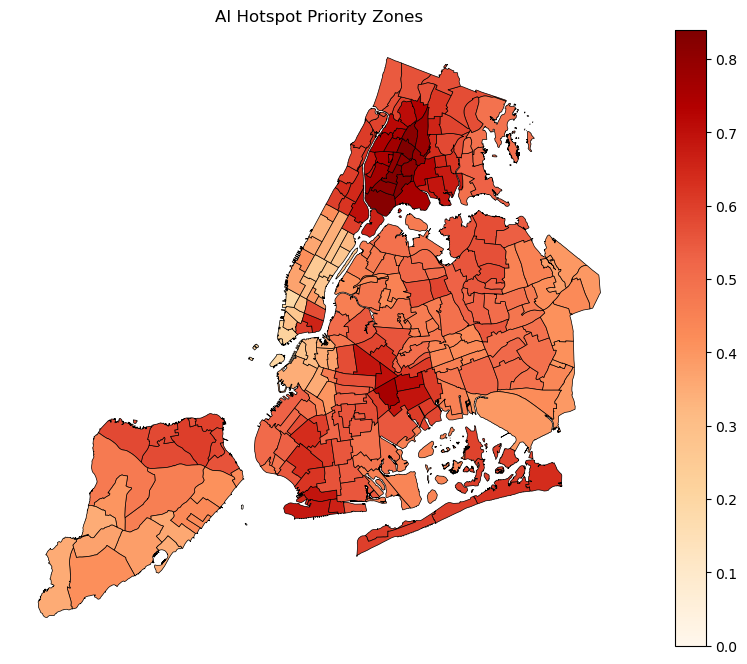

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the exported GeoJSON
gdf = gpd.read_file('zoned_result_export_NTA.geojson')

# 2. Quick check of the data
display(gdf.head())

# 3. Plot it! 
# We can use your new 'hotspot_score' column to color the map (Choropleth)
fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(
    column='hotspot_score', # Change this to whatever property you want to map
    cmap='OrRd',            # Orange-Red color palette (like your Fire palette)
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)
ax.set_title('AI Hotspot Priority Zones')
plt.axis('off') # Hides the lat/lon axes for a cleaner look
plt.show()

### Publication-Ready Hotspot Map with Ground Truth Overlay

This cell produces a **publication-quality visualization** combining AI-generated hotspot zones with actual after-school locations.

#### Map Composition
- **Base layer (polygons):**
  - Plots Neighborhood Tabulation Areas colored by `hotspot_score`.
  - Uses a **yellow–orange–red (`YlOrRd`) color scale** to emphasize increasing priority.
  - Thin white boundaries and slight transparency improve visual clarity in dense areas.

- **Overlay (points):**
  - Adds geocoded after-school locations (`gdf_points`) as blue markers.
  - White outlines and reduced marker size prevent occlusion of underlying polygons.

#### Legend and Styling
- Includes a **horizontal colorbar** for the hotspot score, compactly styled for print.
- Adds a separate legend for after-school locations.
- Uses **minimalist styling**:
  - White background for print compatibility
  - Small, high-contrast typography
  - Tight layout and reduced padding

#### Output
- Exports the figure as a **high-resolution PNG (300 DPI)** suitable for academic publication.
- Optionally supports PDF export for vector-based outputs.

**Purpose:**  
This visualization enables **direct visual validation** of the model by comparing predicted high-priority zones with actual intervention sites, supporting the evaluation of spatial alignment and model effectiveness.

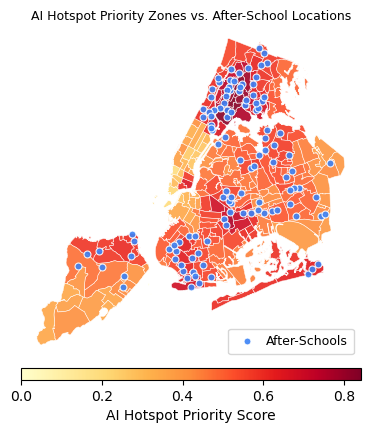

In [17]:
import matplotlib.pyplot as plt

# 1. Wider, shorter figure (e.g., 10 inches wide, 4.5 inches tall)
# Perfect for spanning two columns in an academic paper layout.
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='#ffffff') # Swapped to pure white for print
ax.set_facecolor('#ffffff')

# 2. Plot polygons (Hotspot Zones)
gdf.plot(
    column='hotspot_score',
    cmap='YlOrRd', 
    edgecolor='white',
    linewidth=0.4,       # Thinner lines for a tighter print look
    alpha=0.9,
    legend=True,
    legend_kwds={
        'label': 'AI Hotspot Priority Score',
        'orientation': 'horizontal',
        'shrink': 0.35,      # Drastically shrinks the colorbar length
        'aspect': 30,        # Makes the colorbar much thinner
        'pad': 0.02          # Pulls the colorbar tighter to the bottom of the map
    },
    ax=ax
)

# 3. Overlay points (After-Schools)
# Scaled down the markersize so they don't obscure the polygons in a smaller figure
gdf_points.plot(
    ax=ax,
    color='#3b82f6',     
    edgecolor='white',   
    linewidth=0.8,       
    markersize=25,       # Smaller dots
    alpha=0.9,
    label='After-Schools'
)

# 4. Typography and Legend Styling
ax.set_title(
    'AI Hotspot Priority Zones vs. After-School Locations', 
    fontsize=9,         # Scaled down for print proportion
    fontweight='normal', 
    color='#000000',     # High contrast black for academic print
    pad=1
)

# Style the point legend (Schools)
point_legend = ax.legend(
    loc='lower right',   # Tucks it neatly into a corner (adjust if your map shape overlaps)
    frameon=True, 
    facecolor='white', 
    edgecolor='#cccccc', 
    fontsize=9,          # Smaller text for the legend
    borderpad=0.5,
    handletextpad=0.5
)

# 5. Clean up axes and spacing
plt.axis('off')
plt.tight_layout()

# Save it at print-quality resolution (300 DPI) before showing it!
# plt.savefig('hotspot_map_for_paper.pdf', dpi=300, bbox_inches='tight')

# Save it as a high-quality PNG (300 DPI) before showing it
plt.savefig('hotspot_map_for_paper.png', dpi=300, bbox_inches='tight')

plt.show()

### Quantitative Validation of Hotspot Predictions

This cell evaluates how well the AI-generated hotspot map aligns with actual after-school locations using a **spatial join and threshold-based analysis**.

#### Spatial Alignment
- Performs a **spatial join** between after-school locations (`gdf_points`) and neighborhood zones (`gdf`).
- Assigns each school the corresponding **`hotspot_score`** of the zone it falls within.
- Filters out points that do not intersect any zone to ensure valid comparisons.

#### Threshold-Based Evaluation
- Tests multiple **quantile thresholds** (50%, 60%, 70%) to define “high-priority” zones.
- For each threshold:
  - Computes the **score cutoff** based on the distribution of `hotspot_score`.
  - Identifies zones above this cutoff as priority areas.

#### Metrics Computed
- **Coverage:** Proportion of after-school sites located within high-priority zones.
- **Counts:** Number of sites captured (`num_high`) out of total valid sites (`num_total`).
- **Baseline:** Expected coverage under random selection (i.e., top \(1 - q\)% of zones).
- **Lift:** Ratio of observed coverage to baseline, measuring improvement over random.

#### Output
- Results are stored in a structured DataFrame (`results_df`) for easy inspection.
- Additional formatted print statements provide a clear, human-readable summary.

**Purpose:**  
This step provides a **quantitative validation framework**, demonstrating how effectively the AI-derived priority map captures real-world intervention sites and assessing its performance relative to random allocation.

In [7]:
import geopandas as gpd
import pandas as pd

# 1. Spatial join (assign each point to a zone)
joined = gpd.sjoin(gdf_points, gdf, how="left", predicate="within")

# 2. Drop points that don't fall in any zone
valid = joined.dropna(subset=["hotspot_score"])

# 3. Sensitivity analysis over multiple thresholds
quantiles = [0.5, 0.6, 0.7]
results = []

for q in quantiles:
    # # 1. Spatial join (assign each point to a zone)
    # joined = gpd.sjoin(gdf_points, gdf, how="left", predicate="within")
    
    # # 2. Drop points that don't fall in any zone
    # valid = joined.dropna(subset=["hotspot_score"])


    # threshold for top (1 - q)% zones
    threshold = gdf["hotspot_score"].quantile(q)
    # threshold = gdf["hotspot_score"].quantile(q)

    
    # coverage: proportion of points in zones above threshold
    coverage = (valid["hotspot_score"] > threshold).mean()
    
    # counts
    num_total = len(valid)
    num_high = (valid["hotspot_score"] > threshold).sum()
    
    # baseline (random expectation)
    baseline = 1 - q
    
    # lift (how much better than random)
    lift = coverage / baseline if baseline > 0 else None
    
    results.append({
        "quantile": q,
        "threshold": threshold,
        "coverage": coverage,
        "num_high": num_high,
        "num_total": num_total,
        "baseline": baseline,
        "lift": lift
    })

# 4. Convert to DataFrame for clean display
results_df = pd.DataFrame(results)

print(results_df)

# 5. Optional: pretty print
for r in results:
    print(f"\nTop {int((1 - r['quantile']) * 100)}% zones (q={r['quantile']}):")
    print(f"  Threshold: {r['threshold']:.3f}")
    print(f"  Coverage: {r['coverage']:.3f}")
    print(f"  {r['num_high']} / {r['num_total']} points")
    print(f"  Baseline (random): {r['baseline']:.3f}")
    print(f"  Lift: {r['lift']:.2f}")

   quantile  threshold  coverage  num_high  num_total  baseline      lift
0       0.5   0.529566  0.771930        88        114       0.5  1.543860
1       0.6   0.557464  0.692982        79        114       0.4  1.732456
2       0.7   0.584044  0.561404        64        114       0.3  1.871345

Top 50% zones (q=0.5):
  Threshold: 0.530
  Coverage: 0.772
  88 / 114 points
  Baseline (random): 0.500
  Lift: 1.54

Top 40% zones (q=0.6):
  Threshold: 0.557
  Coverage: 0.693
  79 / 114 points
  Baseline (random): 0.400
  Lift: 1.73

Top 30% zones (q=0.7):
  Threshold: 0.584
  Coverage: 0.561
  64 / 114 points
  Baseline (random): 0.300
  Lift: 1.87


### Interactive Map of After-School Locations

This cell creates an **interactive web map** to explore the spatial distribution of after-school program sites across New York City.

#### Visual Encoding
- **Color (Borough):**
  - Each borough is assigned a distinct color (e.g., Bronx = red, Brooklyn = blue).
- **Icon Shape (Year):**
  - **Circle** → Fall 2025 openings  
  - **Star** → Fall 2026 openings  

#### Map Construction
- Initializes a **Folium map** centered on NYC using a light basemap (`CartoDB positron`).
- Organizes schools into **borough-specific layers** (`FeatureGroup`) to enable interactive toggling.
- Adds **markers** for each school:
  - Includes a styled popup with name, address, borough, and opening year.
  - Displays tooltips for quick identification.

#### Interactivity
- **Layer control panel** allows users to toggle borough visibility.
- Custom **HTML legend** explains both color (borough) and icon (year) encodings.
- Clean UI styling ensures readability and usability.

#### Output
- Saves the map as an interactive HTML file (`nyc_schools_map.html`).
- Displays the map inline within the notebook.

**Purpose:**  
This interactive visualization supports **exploratory analysis and communication**, allowing users to examine the geographic distribution of after-school sites and understand their temporal and borough-level patterns.

In [15]:
# Color scheme: by borough
BOROUGH_COLORS = {
    "Bronx":       "red",
    "Brooklyn":    "blue",
    "Manhattan":   "purple",
    "Queens":      "orange",
    "Staten Island": "green",
}

# Icon scheme: by year
YEAR_ICONS = {
    "Fall 2025": "circle",
    "Fall 2026": "star",
}

# Create the map centered on NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="CartoDB positron")

# Add a layer for each borough for toggling
borough_groups = {b: folium.FeatureGroup(name=f"{b} ({BOROUGH_COLORS[b]})") for b in BOROUGH_COLORS}

for _, row in df.dropna(subset=['lat', 'lon']).iterrows():
    color = BOROUGH_COLORS.get(row['borough'], 'gray')
    icon_name = "circle" if row['year'] == "Fall 2025" else "star"
    
    popup_html = f"""
    <div style='font-family: Arial; width: 200px;'>
        <b style='font-size:13px;'>{row['name']}</b><br>
        <hr style='margin:4px 0;'>
        <span style='color:#555;'>📍 {row['address']}</span><br>
        <span style='color:#555;'>🏙️ {row['borough']}</span><br>
        <span style='color:#555;'>📅 {row['year']}</span>
    </div>
    """
    
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=row['name'],
        icon=folium.Icon(color=color, icon=icon_name, prefix='fa')
    ).add_to(borough_groups[row['borough']])

# Add all groups to map
for group in borough_groups.values():
    group.add_to(nyc_map)

# Layer control
folium.LayerControl(collapsed=False).add_to(nyc_map)

# Legend
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background-color: white; padding: 15px; border-radius: 8px;
            border: 1px solid #ccc; font-family: Arial; font-size: 13px; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
  <b style='font-size:14px;'>NYC Schools</b><br><br>
  <b>Borough</b><br>
  <span style='color:red;'>●</span> Bronx<br>
  <span style='color:blue;'>●</span> Brooklyn<br>
  <span style='color:purple;'>●</span> Manhattan<br>
  <span style='color:orange;'>●</span> Queens<br>
  <span style='color:green;'>●</span> Staten Island<br><br>
  <b>Opening Year</b><br>
  ⭕ Fall 2025 (circle)<br>
  ⭐ Fall 2026 (star)
</div>
"""
nyc_map.get_root().html.add_child(folium.Element(legend_html))

# Save and display
nyc_map.save("nyc_schools_map.html")
print("Map saved as 'nyc_schools_map.html'")
nyc_map  # Display inline in Jupyter

Map saved as 'nyc_schools_map.html'
